In [28]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/home/eungyeop/LLM/tabular/ProtoLLM_entropic20251217')
sys.path.append(str(root_dir))

from models.TabularFLM_S_ import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records_till20260320/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1.0_alpha-0.5_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-EXP3_REG_ALPHA05_FGW1/50/20260318_140439/best_joint.pt"
#올바름 ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records_till_20260317/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/best_joint.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.3_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-None/50/20260410_031653/best_joint.pt"
target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records_till_20260317/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-XTFORMER_EVALUATION100/50/20260225_221853/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260225_221853.pt"
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()

Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x ModuleList(
        (0-1): 2 x lightGraphNeuralNet(
          (dropout): Dropout(p=0.1, inplace=False)
          (linear): Linear(in_features=768, out_features=192, bias=True)
          (update): Linear(in_features=192, out_features=768, bias=True)
          (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (attn): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): Tanh()
          (2): Linear(in_features=192, out_features=1, bias=True)
        )
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
 

## Source Loading

In [29]:
args2 = args
fix_seed(args2.random_seed)

sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src, is_source=True)
    tr, va, te = res['loaders']

    from torch.utils.data import ConcatDataset, DataLoader
    datasets = [l.dataset for l in [tr, va, te] if l is not None]
    ds = ConcatDataset(datasets)

    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)

>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 1121
[Source] Validation data size: 198
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 850
[Source] Validation data size: 150
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 50
[Source] Training data size: 229
[Source] Va

## Basis Risk Verification

One-Hot Basis Risk (model intrinsic)
  M = 8 bases
  B0: one-hot prob = 0.1167 → LOW risk
  B1: one-hot prob = 0.5238 → HIGH risk
  B2: one-hot prob = 0.0884 → LOW risk
  B3: one-hot prob = 0.9767 → HIGH risk
  B4: one-hot prob = 0.6806 → HIGH risk
  B5: one-hot prob = 0.9972 → HIGH risk
  B6: one-hot prob = 0.0584 → LOW risk
  B7: one-hot prob = 0.0181 → LOW risk

Per-Source Basis Label Ratio

  [Medicaldataset] N=1319, overall pos=0.614
    B0: n=   3, pos_rate=1.000
    B1: n= 543, pos_rate=0.344
    B2: n=   9, pos_rate=0.889
    B3: n= 546, pos_rate=0.984
    B4: n=  48, pos_rate=0.479
    B5: n=  22, pos_rate=1.000
    B6: n= 147, pos_rate=0.204
    B7: n=   1, pos_rate=0.000

  [Cardiovascular_Disease] N=1000, overall pos=0.580
    B0: n=  69, pos_rate=0.884
    B1: n=   0, pos_rate=nan
    B2: n= 404, pos_rate=0.134
    B3: n= 324, pos_rate=0.938
    B4: n=   6, pos_rate=0.000
    B5: n= 161, pos_rate=0.944
    B6: n=  36, pos_rate=0.250
    B7: n=   0, pos_rate=nan

  [Heart_d

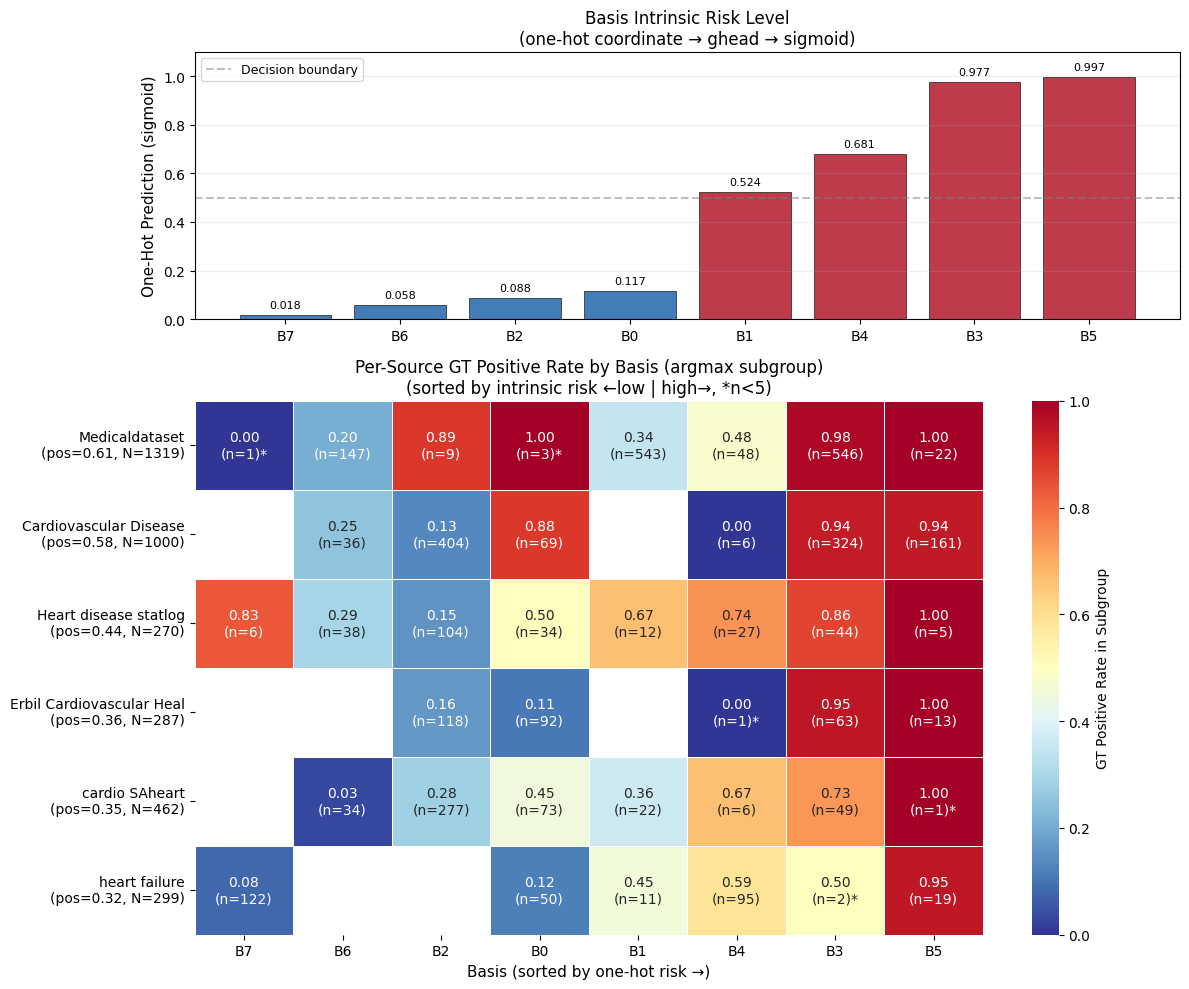


Risk Consistency Analysis
  High-risk bases (one-hot > 0.5): ['B1', 'B3', 'B4', 'B5']
  Low-risk bases (one-hot ≤ 0.5):  ['B0', 'B2', 'B6', 'B7']

  [Medicaldataset]
    High-risk bases: avg pos_rate = 0.664 (n=1159)
    Low-risk bases:  avg pos_rate = 0.256 (n=160)
    → ✓ CONSISTENT

  [Cardiovascular_Disease]
    High-risk bases: avg pos_rate = 0.929 (n=491)
    Low-risk bases:  avg pos_rate = 0.244 (n=509)
    → ✓ CONSISTENT

  [Heart_disease_statlog]
    High-risk bases: avg pos_rate = 0.807 (n=88)
    Low-risk bases:  avg pos_rate = 0.269 (n=182)
    → ✓ CONSISTENT

  [Erbil_Cardiovascular_Heal]
    High-risk bases: avg pos_rate = 0.948 (n=77)
    Low-risk bases:  avg pos_rate = 0.138 (n=210)
    → ✓ CONSISTENT

  [cardio_SAheart]
    High-risk bases: avg pos_rate = 0.628 (n=78)
    Low-risk bases:  avg pos_rate = 0.289 (n=384)
    → ✓ CONSISTENT

  [heart_failure_clinical_re]
    High-risk bases: avg pos_rate = 0.630 (n=127)
    Low-risk bases:  avg pos_rate = 0.093 (n=172)
   

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


@torch.no_grad()
def compute_onehot_basis_risk(model, device):
    model.eval()
    lcg_feat, lcg_struct = model.latent_graph()
    M = lcg_feat.shape[0]
    expert_outputs = model.gnn_experts(lcg_feat.unsqueeze(0), lcg_struct.unsqueeze(0))

    print(f"{'='*60}")
    print(f"One-Hot Basis Risk (model intrinsic)")
    print(f"{'='*60}")
    print(f"  M = {M} bases")

    onehot_probs = []
    for k in range(M):
        pi_onehot = torch.zeros(1, M, device=device)
        pi_onehot[0, k] = 1.0
        weighted = (pi_onehot.unsqueeze(-1) * expert_outputs).sum(dim=1)
        current_mode = getattr(model, 'mode', 'Full')
        if current_mode == 'Few':
            logit = model.ghead2(weighted)
        else:
            logit = model.ghead(weighted)
        prob = torch.sigmoid(logit).item()
        onehot_probs.append(prob)
        risk_label = "HIGH" if prob > 0.5 else "LOW"
        print(f"  B{k}: one-hot prob = {prob:.4f} \u2192 {risk_label} risk")

    return np.array(onehot_probs)


@torch.no_grad()
def compute_per_source_basis_label_ratio(model, loaders, sources, device):
    model.eval()
    all_results = {}

    for src_name in sources:
        loader = loaders[src_name]
        all_pi, all_y = [], []

        for batch in loader:
            batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                       for k, v in batch.items()}
            out = model.predict(batch_t, return_all=True)
            pi = model.graph_quantizer.last_pi
            all_pi.append(pi.cpu().numpy())
            all_y.append(batch_t['y'].cpu().view(-1).numpy())

        pis = np.concatenate(all_pi, axis=0)
        ys = np.concatenate(all_y, axis=0).astype(int)
        argmax = pis.argmax(axis=1)
        M = pis.shape[1]

        basis_info = {}
        for k in range(M):
            mask = (argmax == k)
            n = mask.sum()
            if n > 0:
                pos_rate = ys[mask].mean()
                n_pos = ys[mask].sum()
            else:
                pos_rate = np.nan
                n_pos = 0
            basis_info[k] = {'n': int(n), 'n_pos': int(n_pos), 'pos_rate': float(pos_rate)}

        all_results[src_name] = {
            'basis_info': basis_info,
            'M': M,
            'N': len(ys),
            'overall_pos': float(ys.mean()),
        }

    return all_results


def plot_basis_risk_verification(onehot_probs, source_results, sources):
    M = len(onehot_probs)
    n_src = len(sources)

    short_names = [s.replace('_Dataset', '').replace('_Health_Dataset', '')
                     .replace('_clinical_records', '').replace('_', ' ')[:25]
                   for s in sources]
    sorted_idx = np.argsort(onehot_probs)

    fig, axes = plt.subplots(2, 1, figsize=(max(10, M * 1.5), 10),
                              gridspec_kw={'height_ratios': [1, 2]})

    ax = axes[0]
    colors = ['#2166ac' if p < 0.5 else '#b2182b' for p in onehot_probs[sorted_idx]]
    bars = ax.bar(range(M), onehot_probs[sorted_idx], color=colors, alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')
    for i, (bar, idx) in enumerate(zip(bars, sorted_idx)):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{onehot_probs[idx]:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(M))
    ax.set_xticklabels([f'B{idx}' for idx in sorted_idx], fontsize=10)
    ax.set_ylabel('One-Hot Risk', fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_title('', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

    ax = axes[1]
    heatmap_data = np.full((n_src, M), np.nan)
    annot_data = np.full((n_src, M), '', dtype=object)
    for i, src_name in enumerate(sources):
        info = source_results[src_name]['basis_info']
        for j, basis_idx in enumerate(sorted_idx):
            bi = info[basis_idx]
            if bi['n'] >= 5:
                heatmap_data[i, j] = bi['pos_rate']
                annot_data[i, j] = f"{bi['pos_rate']:.2f}\n(n={bi['n']})"
            elif bi['n'] > 0:
                heatmap_data[i, j] = bi['pos_rate']
                annot_data[i, j] = f"{bi['pos_rate']:.2f}\n(n={bi['n']})*"
    y_labels = [f"{sn}\n(pos={source_results[s]['overall_pos']:.2f}, N={source_results[s]['N']})"
                for sn, s in zip(short_names, sources)]
    sns.heatmap(
        heatmap_data, annot=annot_data, fmt='',
        xticklabels=[f'B{idx}' for idx in sorted_idx],
        yticklabels=y_labels,
        cmap='RdYlBu_r', center=0.5, vmin=0, vmax=1,
        linewidths=0.5, ax=ax,
        cbar_kws={'label': 'GT Positive Rate in Subgroup'},
    )
    ax.set_title('Per-Source GT Positive Rate by Basis (argmax subgroup)\n'
                 '(sorted by intrinsic risk \u2190low | high\u2192, *n<5)', fontsize=12)
    ax.set_xlabel('Basis (sorted by one-hot risk \u2192)', fontsize=11)
    plt.tight_layout()
    plt.show()


def analyze_risk_consistency(onehot_probs, source_results, sources):
    M = len(onehot_probs)
    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    low_risk_bases = [k for k in range(M) if onehot_probs[k] <= 0.5]

    print(f"\n{'='*60}")
    print(f"Risk Consistency Analysis")
    print(f"{'='*60}")
    print(f"  High-risk bases (one-hot > 0.5): {['B'+str(k) for k in high_risk_bases]}")
    print(f"  Low-risk bases (one-hot \u2264 0.5):  {['B'+str(k) for k in low_risk_bases]}")

    consistent_count = 0
    total_count = 0
    for src_name in sources:
        info = source_results[src_name]['basis_info']
        high_n, high_pos = 0, 0
        for k in high_risk_bases:
            high_n += info[k]['n']
            high_pos += info[k]['n_pos']
        high_rate = high_pos / max(high_n, 1)
        low_n, low_pos = 0, 0
        for k in low_risk_bases:
            low_n += info[k]['n']
            low_pos += info[k]['n_pos']
        low_rate = low_pos / max(low_n, 1)
        is_consistent = high_rate > low_rate
        if is_consistent:
            consistent_count += 1
        total_count += 1
        short_name = src_name.replace('_Dataset', '')[:25]
        status = "\u2713 CONSISTENT" if is_consistent else "\u2717 INCONSISTENT"
        print(f"\n  [{short_name}]")
        print(f"    High-risk bases: avg pos_rate = {high_rate:.3f} (n={high_n})")
        print(f"    Low-risk bases:  avg pos_rate = {low_rate:.3f} (n={low_n})")
        print(f"    \u2192 {status}")
    print(f"\n  Overall: {consistent_count}/{total_count} sources consistent "
          f"({consistent_count/total_count*100:.0f}%)")


def run_basis_risk_verification(model, loaders, sources, device):
    onehot_probs = compute_onehot_basis_risk(model, device)

    print(f"\n{'='*60}")
    print(f"Per-Source Basis Label Ratio")
    print(f"{'='*60}")
    source_results = compute_per_source_basis_label_ratio(model, loaders, sources, device)
    for src_name in sources:
        r = source_results[src_name]
        short = src_name.replace('_Dataset', '')[:25]
        print(f"\n  [{short}] N={r['N']}, overall pos={r['overall_pos']:.3f}")
        for k in range(r['M']):
            bi = r['basis_info'][k]
            print(f"    B{k}: n={bi['n']:4d}, pos_rate={bi['pos_rate']:.3f}")

    plot_basis_risk_verification(onehot_probs, source_results, sources)
    analyze_risk_consistency(onehot_probs, source_results, sources)

    return {'onehot_probs': onehot_probs, 'source_results': source_results}


risk_result = run_basis_risk_verification(model, loaders, sources, device)

## Basis Risk Verification (Soft Coordinate)

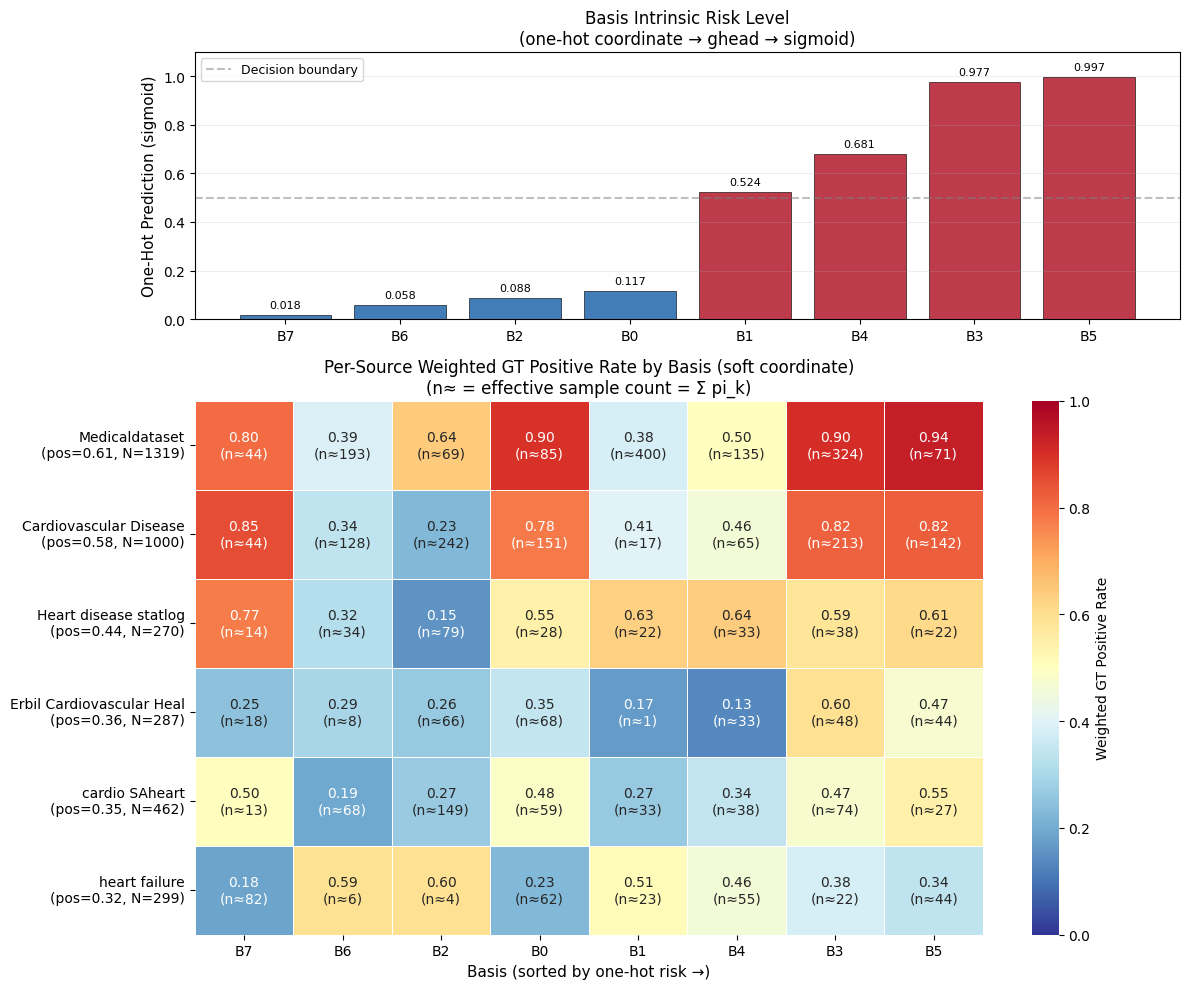


Risk Consistency Analysis (Soft Coordinate)
  High-risk bases: ['B1', 'B3', 'B4', 'B5']
  Low-risk bases:  ['B0', 'B2', 'B6', 'B7']

  [Medicaldataset]
    High-risk: weighted pos_rate = 0.624 (n≈928)
    Low-risk:  weighted pos_rate = 0.591 (n≈391)
    → ✓ CONSISTENT

  [Cardiovascular_Disease]
    High-risk: weighted pos_rate = 0.749 (n≈436)
    Low-risk:  weighted pos_rate = 0.449 (n≈564)
    → ✓ CONSISTENT

  [Heart_disease_statlog]
    High-risk: weighted pos_rate = 0.615 (n≈115)
    Low-risk:  weighted pos_rate = 0.318 (n≈155)
    → ✓ CONSISTENT

  [Erbil_Cardiovascular_Heal]
    High-risk: weighted pos_rate = 0.428 (n≈127)
    Low-risk:  weighted pos_rate = 0.298 (n≈160)
    → ✓ CONSISTENT

  [cardio_SAheart]
    High-risk: weighted pos_rate = 0.415 (n≈173)
    Low-risk:  weighted pos_rate = 0.305 (n≈289)
    → ✓ CONSISTENT

  [heart_failure_clinical_re]
    High-risk: weighted pos_rate = 0.419 (n≈144)
    Low-risk:  weighted pos_rate = 0.230 (n≈155)
    → ✓ CONSISTENT

  Overa

In [31]:
"""Soft coordinate version: weighted positive rate per basis
argmax 대신 pi 값을 weight로 사용
basis k의 weighted pos rate = sum(pi[i,k] * y[i]) / sum(pi[i,k])
→ 모든 sample이 모든 basis에 기여, n이 작아지는 문제 없음
"""


@torch.no_grad()
def compute_per_source_basis_label_ratio_soft(model, loaders, sources, device):
    model.eval()
    all_results = {}

    for src_name in sources:
        loader = loaders[src_name]
        all_pi, all_y = [], []

        for batch in loader:
            batch_t = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                       for k, v in batch.items()}
            out = model.predict(batch_t, return_all=True)
            pi = model.graph_quantizer.last_pi
            all_pi.append(pi.cpu().numpy())
            all_y.append(batch_t['y'].cpu().view(-1).numpy())

        pis = np.concatenate(all_pi, axis=0)  # [N, M]
        ys = np.concatenate(all_y, axis=0).astype(float)  # [N]
        M = pis.shape[1]

        basis_info = {}
        for k in range(M):
            w = pis[:, k]  # [N] — each sample's soft weight for basis k
            w_sum = w.sum()
            if w_sum > 0:
                pos_rate = (w * ys).sum() / w_sum
                n_eff = w_sum  # effective sample count
                n_pos_eff = (w * ys).sum()
            else:
                pos_rate = np.nan
                n_eff = 0
                n_pos_eff = 0
            basis_info[k] = {'n_eff': float(n_eff), 'n_pos_eff': float(n_pos_eff),
                             'pos_rate': float(pos_rate)}

        all_results[src_name] = {
            'basis_info': basis_info,
            'M': M,
            'N': len(ys),
            'overall_pos': float(ys.mean()),
        }

    return all_results


def plot_basis_risk_verification_soft(onehot_probs, source_results, sources):
    M = len(onehot_probs)
    n_src = len(sources)

    short_names = [s.replace('_Dataset', '').replace('_Health_Dataset', '')
                     .replace('_clinical_records', '').replace('_', ' ')[:25]
                   for s in sources]
    sorted_idx = np.argsort(onehot_probs)

    fig, axes = plt.subplots(2, 1, figsize=(max(10, M * 1.5), 10),
                              gridspec_kw={'height_ratios': [1, 2]})

    ax = axes[0]
    colors = ['#2166ac' if p < 0.5 else '#b2182b' for p in onehot_probs[sorted_idx]]
    bars = ax.bar(range(M), onehot_probs[sorted_idx], color=colors, alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')
    for i, (bar, idx) in enumerate(zip(bars, sorted_idx)):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{onehot_probs[idx]:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(M))
    ax.set_xticklabels([f'B{idx}' for idx in sorted_idx], fontsize=10)
    ax.set_ylabel('One-Hot Risk', fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_title('', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

    ax = axes[1]
    heatmap_data = np.full((n_src, M), np.nan)
    annot_data = np.full((n_src, M), '', dtype=object)
    for i, src_name in enumerate(sources):
        info = source_results[src_name]['basis_info']
        for j, basis_idx in enumerate(sorted_idx):
            bi = info[basis_idx]
            if bi['n_eff'] > 0.5:
                heatmap_data[i, j] = bi['pos_rate']
                annot_data[i, j] = f"{bi['pos_rate']:.2f}\n(n\u2248{bi['n_eff']:.0f})"
    y_labels = [f"{sn}\n(pos={source_results[s]['overall_pos']:.2f}, N={source_results[s]['N']})"
                for sn, s in zip(short_names, sources)]
    sns.heatmap(
        heatmap_data, annot=annot_data, fmt='',
        xticklabels=[f'B{idx}' for idx in sorted_idx],
        yticklabels=y_labels,
        cmap='RdYlBu_r', center=0.5, vmin=0, vmax=1,
        linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Weighted GT Positive Rate'},
    )
    ax.set_title('Per-Source Weighted GT Positive Rate by Basis (soft coordinate)\n'
                 '(n\u2248 = effective sample count = \u03a3 pi_k)', fontsize=12)
    ax.set_xlabel('Basis (sorted by one-hot risk \u2192)', fontsize=11)
    plt.tight_layout()
    plt.show()


def analyze_risk_consistency_soft(onehot_probs, source_results, sources):
    M = len(onehot_probs)
    high_risk_bases = [k for k in range(M) if onehot_probs[k] > 0.5]
    low_risk_bases = [k for k in range(M) if onehot_probs[k] <= 0.5]

    print(f"\n{'='*60}")
    print(f"Risk Consistency Analysis (Soft Coordinate)")
    print(f"{'='*60}")
    print(f"  High-risk bases: {['B'+str(k) for k in high_risk_bases]}")
    print(f"  Low-risk bases:  {['B'+str(k) for k in low_risk_bases]}")

    consistent_count = 0
    total_count = 0
    for src_name in sources:
        info = source_results[src_name]['basis_info']
        high_w, high_wp = 0, 0
        for k in high_risk_bases:
            high_w += info[k]['n_eff']
            high_wp += info[k]['n_pos_eff']
        high_rate = high_wp / max(high_w, 1e-8)
        low_w, low_wp = 0, 0
        for k in low_risk_bases:
            low_w += info[k]['n_eff']
            low_wp += info[k]['n_pos_eff']
        low_rate = low_wp / max(low_w, 1e-8)
        is_consistent = high_rate > low_rate
        if is_consistent:
            consistent_count += 1
        total_count += 1
        short_name = src_name.replace('_Dataset', '')[:25]
        status = "\u2713 CONSISTENT" if is_consistent else "\u2717 INCONSISTENT"
        print(f"\n  [{short_name}]")
        print(f"    High-risk: weighted pos_rate = {high_rate:.3f} (n\u2248{high_w:.0f})")
        print(f"    Low-risk:  weighted pos_rate = {low_rate:.3f} (n\u2248{low_w:.0f})")
        print(f"    \u2192 {status}")
    print(f"\n  Overall: {consistent_count}/{total_count} sources consistent "
          f"({consistent_count/total_count*100:.0f}%)")


# 실행 — onehot_probs는 위 셀에서 이미 계산됨
onehot_probs = risk_result['onehot_probs']
source_results_soft = compute_per_source_basis_label_ratio_soft(model, loaders, sources, device)
plot_basis_risk_verification_soft(onehot_probs, source_results_soft, sources)
analyze_risk_consistency_soft(onehot_probs, source_results_soft, sources)

## 1. Ratio Heatmap (basis_pos_rate / source_overall_pos_rate)

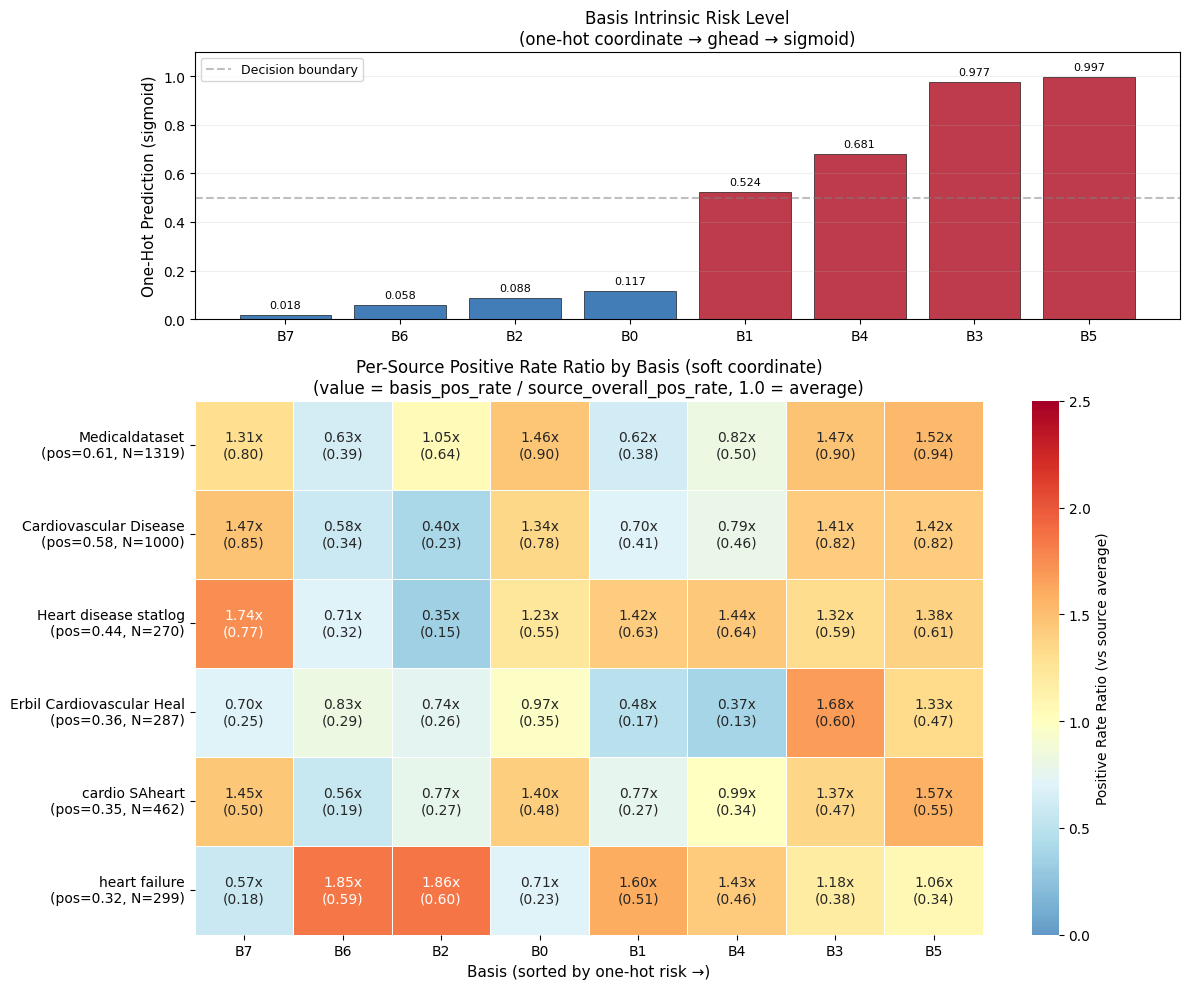

In [32]:
def plot_basis_risk_ratio(onehot_probs, source_results, sources):
    M = len(onehot_probs)
    n_src = len(sources)

    short_names = [s.replace('_Dataset', '').replace('_Health_Dataset', '')
                     .replace('_clinical_records', '').replace('_', ' ')[:25]
                   for s in sources]
    sorted_idx = np.argsort(onehot_probs)

    fig, axes = plt.subplots(2, 1, figsize=(max(10, M * 1.5), 10),
                              gridspec_kw={'height_ratios': [1, 2]})

    # 상단: one-hot risk bar (동일)
    ax = axes[0]
    colors = ['#2166ac' if p < 0.5 else '#b2182b' for p in onehot_probs[sorted_idx]]
    bars = ax.bar(range(M), onehot_probs[sorted_idx], color=colors, alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')
    for i, (bar, idx) in enumerate(zip(bars, sorted_idx)):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{onehot_probs[idx]:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(M))
    ax.set_xticklabels([f'B{idx}' for idx in sorted_idx], fontsize=10)
    ax.set_ylabel('One-Hot Risk', fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_title('', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

    # 하단: ratio heatmap
    ax = axes[1]
    heatmap_data = np.full((n_src, M), np.nan)
    annot_data = np.full((n_src, M), '', dtype=object)
    for i, src_name in enumerate(sources):
        info = source_results[src_name]['basis_info']
        overall = source_results[src_name]['overall_pos']
        for j, basis_idx in enumerate(sorted_idx):
            bi = info[basis_idx]
            if bi['n_eff'] > 0.5 and overall > 0:
                ratio = bi['pos_rate'] / overall
                heatmap_data[i, j] = ratio
                annot_data[i, j] = f"{ratio:.2f}x\n({bi['pos_rate']:.2f})"
    y_labels = [f"{sn}\n(pos={source_results[s]['overall_pos']:.2f}, N={source_results[s]['N']})"
                for sn, s in zip(short_names, sources)]
    sns.heatmap(
        heatmap_data, annot=annot_data, fmt='',
        xticklabels=[f'B{idx}' for idx in sorted_idx],
        yticklabels=y_labels,
        cmap='RdYlBu_r', center=1.0, vmin=0, vmax=2.5,
        linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Positive Rate Ratio'},
    )
    ax.set_title('Per-Source Positive Rate Ratio by Basis (soft coordinate)\n'
                 '(value = basis_pos_rate / source_overall_pos_rate, 1.0 = average)', fontsize=12)
    ax.set_xlabel('Basis (sorted by one-hot risk \u2192)', fontsize=11)
    plt.tight_layout()
    plt.show()


plot_basis_risk_ratio(onehot_probs, source_results_soft, sources)

## 2. Source Functional Similarity Matrix

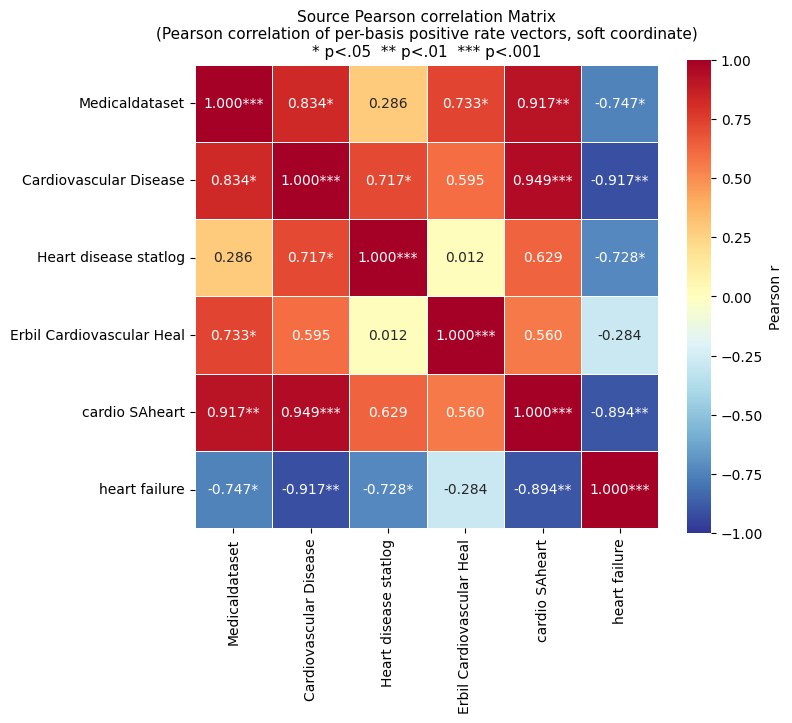


Source Functional Similarity (Pearson r)
  Medicaldataset            vs Cardiovascular Disease   : r=0.8338 (p=0.0101)
  Medicaldataset            vs Heart disease statlog    : r=0.2859 (p=0.4924)
  Medicaldataset            vs Erbil Cardiovascular Heal: r=0.7331 (p=0.0385)
  Medicaldataset            vs cardio SAheart           : r=0.9173 (p=0.0013)
  Medicaldataset            vs heart failure            : r=-0.7473 (p=0.0331)
  Cardiovascular Disease    vs Heart disease statlog    : r=0.7168 (p=0.0454)
  Cardiovascular Disease    vs Erbil Cardiovascular Heal: r=0.5948 (p=0.1199)
  Cardiovascular Disease    vs cardio SAheart           : r=0.9487 (p=0.0003)
  Cardiovascular Disease    vs heart failure            : r=-0.9169 (p=0.0013)
  Heart disease statlog     vs Erbil Cardiovascular Heal: r=0.0120 (p=0.9775)
  Heart disease statlog     vs cardio SAheart           : r=0.6290 (p=0.0948)
  Heart disease statlog     vs heart failure            : r=-0.7281 (p=0.0406)
  Erbil Cardiovascu

In [33]:
from scipy.stats import pearsonr

def plot_source_functional_similarity(source_results, sources, onehot_probs):
    M = len(onehot_probs)
    n_src = len(sources)

    short_names = [s.replace('_Dataset', '').replace('_Health_Dataset', '')
                     .replace('_clinical_records', '').replace('_', ' ')[:25]
                   for s in sources]

    # source별 pos_rate vector (M차원)
    pos_vectors = np.zeros((n_src, M))
    for i, src_name in enumerate(sources):
        info = source_results[src_name]['basis_info']
        for k in range(M):
            pos_vectors[i, k] = info[k]['pos_rate']

    # Pearson correlation matrix
    corr_matrix = np.zeros((n_src, n_src))
    p_matrix = np.zeros((n_src, n_src))
    for i in range(n_src):
        for j in range(n_src):
            r, p = pearsonr(pos_vectors[i], pos_vectors[j])
            corr_matrix[i, j] = r
            p_matrix[i, j] = p

    # annotation: r값 + significance
    annot = np.full((n_src, n_src), '', dtype=object)
    for i in range(n_src):
        for j in range(n_src):
            r = corr_matrix[i, j]
            p = p_matrix[i, j]
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            annot[i, j] = f'{r:.3f}{sig}'

    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    sns.heatmap(
        corr_matrix, annot=annot, fmt='',
        xticklabels=short_names, yticklabels=short_names,
        cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.5, ax=ax, square=True,
        cbar_kws={'label': 'Pearson r'},
    )
    ax.set_title('Source Pearson correlation Matrix\n'
                 '(Pearson correlation of per-basis positive rate vectors, soft coordinate)\n'
                 '* p<.05  ** p<.01  *** p<.001', fontsize=11)
    plt.tight_layout()
    plt.show()

    # 텍스트 요약
    print(f"\n{'='*60}")
    print(f"Source Functional Similarity (Pearson r)")
    print(f"{'='*60}")
    for i in range(n_src):
        for j in range(i+1, n_src):
            r = corr_matrix[i, j]
            p = p_matrix[i, j]
            print(f"  {short_names[i]:25s} vs {short_names[j]:25s}: r={r:.4f} (p={p:.4f})")
    avg_r = corr_matrix[np.triu_indices(n_src, k=1)].mean()
    print(f"\n  Average pairwise r = {avg_r:.4f}")


plot_source_functional_similarity(source_results_soft, sources, onehot_probs)